Si consideri il data set sintetico presente nel file data.csv costituito da 3000 punti 
con  15  feature  numeriche  cadauno  e  una  label  binaria  di  classe  con  valori 
appartenenti a {0, 1}. 
 
 
1. Caricare il dataset, estrarre randomicamente un test set pari al 5% dei dati, 
mantenendo il restante 95% come training set vero e proprio. Calcolare e 
stampare la matrice di correlazione tra le feature e trasformare gli eventuali 
dati  multicollineari  con  una  opportuna  combinazione  lineare.  Infine 
selezionare le feature rilevanti tramite il Fisher score. 
punti ___/ 8 
 
 
2. Implementare un classificatore SVM non lineare per il data set curato come 
al punto precedente con i seguenti iperparametri: 
 
• C = {1, 1/sqrt(n_samples)} 
• kernel=RBF e polinomiale 
• grado del kernek polinomiale = {3, 4} 
 
Usare l’accuracy come metrica e stampare l’accuracy del miglior classificatore 
e la test accuracy ottenuta in predizione. 
punti ___/ 8 
 
 
3. Implementare in Tensorflow una piccola rete neurale densa con almeno due 
layer che esegua la classificazione binaria del data set curato, risultato del 
punto 1. Si utilizzi un opportuno ammontare di dropout sui layer densi ad 
esclusione del primo. La rete sarà addestrata con ottimizzatore RMSProp in 
versione “centrata” con weight decay e momento pari 0.1. Si implementino 
le callback di early stopping, con validation set pari al 10% del training set, una 
pazienza  sulla  validation  loss  di  5  epoche  e  un  incremento  minimo  di 
miglioramento pari a 0.01; infine, la modelcheckpoint salverà solo il miglior 
modello rispetto alla massima validation accuracy. 
punti ___/ 10 
 
 
4. Confrontare  i  risultati  dei  due  classificatori  calcolando  e  stampando,  per 
ciascuno, la matrice di confusione, il valore di accuracy, la ROC e il valore di 
AUC calcolati sul test set. 
punti ___/ 4 
 
 
TOTALE: punti ___/ 30 


In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd 

df = pd.read_csv('../../dbs/data.csv')

df = df.dropna(subset=['class'])


X = df.drop( columns= ['class'])

y = df['class']


X_temp,X_te,y_temp,y_te = train_test_split(X,y, test_size=0.05,random_state=29,stratify=df['class'])
X_tr,X_val,y_tr,y_val = train_test_split(X_temp,y_temp, test_size=10/95, random_state=29)

print(X_tr.shape)


(2550, 15)


In [2]:
#imputazione

print(X_tr.isna().sum())
#non c'è bisogno di imputazione

feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
dtype: int64


In [3]:
print(X_tr.select_dtypes(include=['number']).columns.tolist())
#tutte le feature sono numeriche

['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14']


In [4]:

#ci sono alcune feature molto distanti rispetto alle altre faccio uno sclaing per sicurezza

from sklearn.preprocessing import StandardScaler

print(X_tr.mean())
print(X_tr.var())

scaler = StandardScaler().set_output(transform='pandas')

X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_te = scaler.transform(X_te)




feature_0    -0.005118
feature_1     0.021756
feature_2     0.011643
feature_3     0.978685
feature_4     0.176531
feature_5     0.009846
feature_6    -0.495751
feature_7     0.069104
feature_8    -0.504806
feature_9     0.005311
feature_10   -0.003768
feature_11    0.007520
feature_12    0.057148
feature_13    0.194542
feature_14    0.008863
dtype: float64
feature_0     1.027207
feature_1     1.003726
feature_2     0.982679
feature_3     1.504346
feature_4     6.309359
feature_5     1.017602
feature_6     2.013111
feature_7     2.977527
feature_8     2.632606
feature_9     1.006383
feature_10    0.982013
feature_11    2.494149
feature_12    0.958767
feature_13    3.932490
feature_14    0.996438
dtype: float64



1. Caricare il dataset, estrarre randomicamente un test set pari al 5% dei dati, 
mantenendo il restante 95% come training set vero e proprio. Calcolare e 
stampare la matrice di correlazione tra le feature e trasformare gli eventuali 
dati  multicollineari  con  una  opportuna  combinazione  lineare.  Infine 
selezionare le feature rilevanti tramite il Fisher score. 
punti ___/ 8 

In [5]:


import pandas as pd
import numpy as np

corr_matrix = X_tr.corr().abs()
print(corr_matrix)
threshold = 0.7
feature_comb = []
num_col = len(X_tr.columns)

for i in range(num_col):
    for j in range(i + 1, num_col):
        valore = corr_matrix.iloc[i, j]
        
        if valore > threshold:
            col_comb = corr_matrix.columns[j]
            row_comb = corr_matrix.index[i]  
            
            inserted = False
            for gruppo in feature_comb:
                if col_comb in gruppo or row_comb in gruppo:
                    if col_comb not in gruppo:
                        gruppo.append(col_comb)
                    if row_comb not in gruppo:
                        gruppo.append(row_comb)
                    inserted = True
                    break  
            
            if not inserted:
                feature_comb.append([col_comb, row_comb])

x_tr = X_tr.copy()
x_val = X_val.copy()
x_te = X_te.copy()
col_list = []          

for idx, gruppo in enumerate(feature_comb):
    name_f = f'feature_add_{idx + 1}'
    
    x_tr[name_f] = X_tr[gruppo].mean(axis=1)
    x_val[name_f] = X_val[gruppo].mean(axis=1)
    x_te[name_f] = X_te[gruppo].mean(axis=1)
    
    for col in gruppo:
        if col not in col_list:
            col_list.append(col)

X_tr = x_tr.drop(columns=col_list)
X_val = x_val.drop(columns=col_list)
X_te = x_te.drop(columns=col_list)

print("Gruppi di feature correlate identificati:", feature_comb)
print(X_tr.shape)

            feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
feature_0    1.000000   0.022938   0.009015   0.012884   0.016102   0.002425   
feature_1    0.022938   1.000000   0.018027   0.032033   0.004604   0.001753   
feature_2    0.009015   0.018027   1.000000   0.002896   0.017760   0.001065   
feature_3    0.012884   0.032033   0.002896   1.000000   0.168253   0.010632   
feature_4    0.016102   0.004604   0.017760   0.168253   1.000000   0.011492   
feature_5    0.002425   0.001753   0.001065   0.010632   0.011492   1.000000   
feature_6    0.012769   0.009624   0.002228   0.085983   0.083091   0.006580   
feature_7    0.025271   0.003387   0.019508   0.085805   0.681174   0.005063   
feature_8    0.005870   0.000310   0.014773   0.201997   0.824851   0.021325   
feature_9    0.000992   0.014826   0.008684   0.038543   0.004278   0.001181   
feature_10   0.035502   0.001670   0.021963   0.006341   0.010561   0.043619   
feature_11   0.015594   0.008713   0.001

Quando utilizzi SelectKBest accoppiato a f_classif (che implementa il test statistico ANOVA), l'algoritmo calcola per ogni singola feature un punteggio basato sul rapporto tra due varianze:$$F = \frac{\text{Varianza Inter-Classe (Between-group Variance)}}{\text{Varianza Intra-Classe (Within-group Variance)}}$$Varianza Inter-Classe (Numeratore): Misura quanto le medie delle diverse classi (es. la classe 0 e la classe 1) siano distanti tra loro lungo l'asse di quella specifica feature. Più le medie sono distanti, più la feature aiuta a separare i gruppi.Varianza Intra-Classe (Denominatore): Misura quanto i punti appartenenti alla stessa classe siano dispersi o "sparpagliati" attorno alla loro media. Più i punti sono compatti (varianza bassa), meglio è.Di conseguenza, uno score molto alto indica una feature eccellente: significa che le classi sono geometricamente ben distanziate tra loro e, al tempo stesso, molto compatte al loro interno.

[np.float64(1536.618945938984), np.float64(369.11894630337594), np.float64(54.58983229496583), np.float64(2.6229269740905408), np.float64(1.6564020131604937), np.float64(0.8798911605666211), np.float64(0.6846739226350154), np.float64(0.6842926870333624), np.float64(0.6221216903181022), np.float64(0.5989347849119094), np.float64(0.1591091343030583), np.float64(0.006102805664755714), np.float64(0.005519729024023475)]


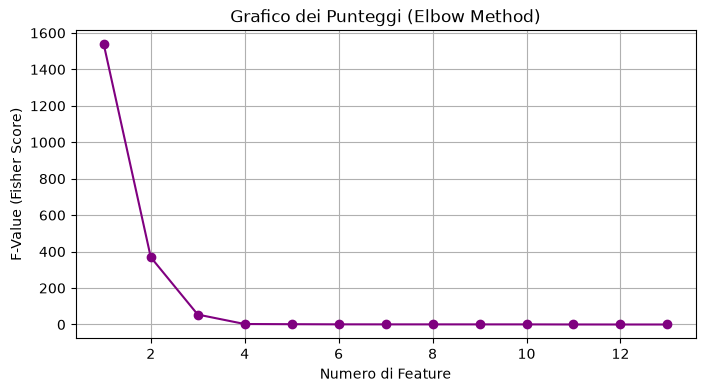

In [6]:


from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt

selector = SelectKBest(score_func=f_classif, k='all').fit(X_tr, y_tr)
scores = sorted(selector.scores_, reverse=True)
print(scores)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(scores) + 1), scores, marker='o', color='purple')
plt.title("Grafico dei Punteggi (Elbow Method)")
plt.xlabel("Numero di Feature")
plt.ylabel("F-Value (Fisher Score)")
plt.grid(True)
plt.show()



In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=2).set_output(transform='pandas')

X_tr = selector.fit_transform( X_tr, y_tr )
X_val = selector.transform(X_val)
X_te = selector.transform( X_te )



2. Implementare un classificatore SVM non lineare per il data set curato come 
al punto precedente con i seguenti iperparametri: 
 
• C = {1, 1/sqrt(n_samples)} 
• kernel=RBF e polinomiale 
• grado del kernek polinomiale = {3, 4} 
 
Usare l’accuracy come metrica e stampare l’accuracy del miglior classificatore 
e la test accuracy ottenuta in predizione. 
punti ___/ 8 

4. Confrontare  i  risultati  dei  due  classificatori  calcolando  e  stampando,  per 
ciascuno, la matrice di confusione, il valore di accuracy, la ROC e il valore di 
AUC calcolati sul test set. 
punti ___/ 4 

In [9]:
import matplotlib.pyplot as plt  # CORRETTO: Aggiunto l'import per i grafici
from numpy import sqrt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    ConfusionMatrixDisplay, 
    RocCurveDisplay
)

param_grid = [
    # Combinazioni per il kernel RBF
    {
        'kernel': ['rbf'],
        'C': [1, 1 / sqrt(len(X_tr))]
    },
    # Combinazioni per il kernel Polinomiale con i relativi gradi
    {
        'kernel': ['poly'],
        'C': [1, 1 / sqrt(len(X_tr))],
        'degree': [3, 4]
    }
]

search_grid = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    scoring='accuracy' 
)

search_grid.fit(X_tr, y_tr)

best_model = search_grid.best_estimator_
best_params = search_grid.best_params_
best_cv_accuracy = search_grid.best_score_ 

print(f"Miglior classificatore (CV Accuracy): {best_cv_accuracy:.4f}")
print(f"Iperparametri ottimali: {best_params}")

name_model = f'parametri: {best_params}'

y_pred = best_model.predict(X_te)
y_pred_prob = best_model.predict_proba(X_te)[:, 1]

# NOTA: C'era un piccolo typo in test_accuracy (avevi scritto accurancy)
test_accuracy = accuracy_score(y_te, y_pred)
print(f"Test Accuracy ottenuta in predizione: {test_accuracy:.4f}")




d:\Università\bigdata\workspace\big-data\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Università\bigdata\workspace\big-data\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Università\bigdata\workspace\big-data\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Università\bigdata\workspace\big-data\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter

Miglior classificatore (CV Accuracy): 0.8655
Iperparametri ottimali: {'C': np.float64(0.019802950859533486), 'kernel': 'rbf'}
Test Accuracy ottenuta in predizione: 0.8667


3. Implementare in Tensorflow una piccola rete neurale densa con almeno due 
layer che esegua la classificazione binaria del data set curato, risultato del 
punto 1. Si utilizzi un opportuno ammontare di dropout sui layer densi ad 
esclusione del primo. La rete sarà addestrata con ottimizzatore RMSProp in 
versione “centrata” con weight decay e momento pari 0.1. Si implementino 
le callback di early stopping, con validation set pari al 10% del training set, una 
pazienza  sulla  validation  loss  di  5  epoche  e  un  incremento  minimo  di 
miglioramento pari a 0.01; infine, la modelcheckpoint salverà solo il miglior 
modello rispetto alla massima validation accuracy. 
punti ___/ 10 

In [ ]:

from torch.utils.data import Dataset
import torch
import numpy as np
import torchnn as utils

class MyDataset(Dataset):
    
    def __init__(self,X,y):
        
        self.X = torch.tensor( X, dtype=torch.float32 )
        self.y = torch.tensor( y, dtype=torch.long )
        print(self.y.shape)
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]

train_dataloader, val_dataloader, test_dataloader = utils.make_dataloaders(
    MyDataset(np.array(X_tr), np.array(y_tr)),
    MyDataset(np.array(X_val), np.array(y_val)),
    MyDataset(np.array(X_te), np.array(y_te)),
)

        
        

torch.Size([2550])
torch.Size([300])
torch.Size([150])
Shape e tipo dei campioni: torch.Size([64, 2]), torch.float32
Shape e tipo delle etichette: torch.Size([64]) torch.int64


In [34]:
from torch import nn
import copy

class Net(nn.Module):
    def __init__(self, depth, hidden_size):
        super().__init__()
        
        self.activation = nn.ReLU()
        layers = [ nn.Linear(X_tr.shape[1],hidden_size), self.activation ]
        
        for _ in range(depth-2):
            layers += [ nn.Dropout(0.2) ,nn.Linear(hidden_size,hidden_size), self.activation ]
            
        layers += [ nn.Linear(hidden_size,2), nn.LogSoftmax() ]
        self.layers = nn.Sequential(*layers)
    
    def forward(self,X):
        return self.layers(X)
    
model = Net(4,64)
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu' )
model = model.to(device)

op = torch.optim.RMSprop(params=model.parameters(), weight_decay=0.01, centered=True, momentum=0.1)
early_stopping = utils.EarlyStopping(patience=5,min_delta=0.01)
criterion = nn.NLLLoss()

class SaveBestModel:
    def __init__(self):
        self.acc = -1
        self.model = None
        self.op = None
    
    def __call__(self, model, op, acc,epoch,train_loss, val_loss, metrics):
        
        if acc < self.acc:
            return
        
        self.acc = acc
        self.model = copy.deepcopy(model.state_dict())
        self.op = copy.deepcopy(op.state_dict())
        self.epoch = epoch
        self.train_loss = train_loss
        self.val_loss = val_loss
        self.metrics = metrics
        
    def save_model(self, path):

    
        torch.save(  {
                'epoch': self.epoch,
                'model_state_dict': self.model,               
                'optimizer_state_dict': self.op,     
                'training_loss': self.train_loss,
                'validation_loss': self.val_loss,
                'accuracy': self.acc
        },path)
            

In [41]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score


def eval_loop(model, dataloader, device, loss_fn):

    model.eval()

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accuracy = 0.0, 0

    y_true = []
    y_pred = []
    y_pred_prob = []

    # context manager che disabilita esplicitamente il calcolo dei gradienti in fase di test
    with torch.no_grad():
        for X, y in dataloader:

            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            accuracy += (pred.argmax(1) == y).type(torch.float).sum().item()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.argmax(1).cpu().numpy())
            y_pred_prob.extend( torch.exp(pred).cpu().numpy() )

    test_loss /= num_batches
    accuracy /= size    
  
    
    auc = roc_auc_score(y_true, np.array(y_pred_prob)[:,1])   

    return test_loss, accuracy, auc, (y_true,y_pred,y_pred_prob)


3. Implementare in Tensorflow una piccola rete neurale densa con almeno due 
layer che esegua la classificazione binaria del data set curato, risultato del 
punto 1. Si utilizzi un opportuno ammontare di dropout sui layer densi ad 
esclusione del primo. La rete sarà addestrata con ottimizzatore RMSProp in 
versione “centrata” con weight decay e momento pari 0.1. Si implementino 
le callback di early stopping, con validation set pari al 10% del training set, una 
pazienza  sulla  validation  loss  di  5  epoche  e  un  incremento  minimo  di 
miglioramento pari a 0.01; infine, la modelcheckpoint salverà solo il miglior 
modello rispetto alla massima validation accuracy. 
punti ___/ 10 

In [44]:

from tqdm import trange


scheduler = torch.optim.lr_scheduler.LinearLR( op, start_factor=1.0, end_factor=0.1, total_iters=30 )                  
epochs = 30
# liste dei valori di loss e accuracy epoca per epoca per il plot
train_loss,validation_loss = [],[]
accuracy = []
metrics = {
    'auc' : [],
}

bm = SaveBestModel()
num_batches = len(train_dataloader.batch_sampler) 

# Ciclo di addestramento con early stopping
for epoch in range(1,epochs+1):

    # Progress bar
    pbar = trange(num_batches)
    pbar.set_description(desc='Epoch {:4d}'.format(epoch))

    epoch_train_loss = utils.train_loop(model, train_dataloader, op, device, pbar, loss_fn=criterion)
    train_loss.append(epoch_train_loss)
    
    epoch_validate_loss, accuracy, auc, pred = eval_loop(model, val_dataloader, device, loss_fn=criterion)
    validation_loss.append(epoch_validate_loss)

    val_str = f'Validation loss: {epoch_validate_loss:6.4f}\n' if val_dataloader != None else ' '
    print(f"Train loss: {epoch_train_loss:6.4f}\n{val_str}")

    metrics['auc'].append( auc)

    bm(model,op,accuracy,epoch,epoch_train_loss,epoch_validate_loss, metrics)
    
    early_stopping(validation_loss=epoch_validate_loss)
   
    if early_stopping.early_stop:
        break

    if scheduler is not None:
        scheduler.step()



Epoch    1:   0%|          | 0/40 [00:00<?, ?it/s]d:\Università\bigdata\workspace\big-data\Lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
Epoch    1: 100%|██████████| 40/40 [00:00<00:00, 352.19it/s]


Train loss: 0.3620
Validation loss: 0.3388



Epoch    2:   0%|          | 0/40 [00:00<?, ?it/s]d:\Università\bigdata\workspace\big-data\Lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
Epoch    2: 100%|██████████| 40/40 [00:00<00:00, 366.62it/s]


Train loss: 0.3531
Validation loss: 0.3653



Epoch    3:   0%|          | 0/40 [00:00<?, ?it/s]d:\Università\bigdata\workspace\big-data\Lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
Epoch    3: 100%|██████████| 40/40 [00:00<00:00, 384.42it/s]


...

Train loss: 0.3553
Validation loss: 0.3722



Epoch    5:   0%|          | 0/40 [00:00<?, ?it/s]d:\Università\bigdata\workspace\big-data\Lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
Epoch    5: 100%|██████████| 40/40 [00:00<00:00, 380.72it/s]


Train loss: 0.3573
Validation loss: 0.3575



Epoch    6:   0%|          | 0/40 [00:00<?, ?it/s]d:\Università\bigdata\workspace\big-data\Lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
Epoch    6: 100%|██████████| 40/40 [00:00<00:00, 395.90it/s]

Train loss: 0.3562
Validation loss: 0.3304



In [48]:
model.load_state_dict( bm.model )
op.load_state_dict( bm.op )
epoch_validate_loss, accuracy, auc, pred = eval_loop(model, test_dataloader, device, loss_fn=criterion)

d:\Università\bigdata\workspace\big-data\Lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


4. Confrontare  i  risultati  dei  due  classificatori  calcolando  e  stampando,  per 
ciascuno, la matrice di confusione, il valore di accuracy, la ROC e il valore di 
AUC calcolati sul test set. 
punti ___/ 4 

0.8933333333333333
0.8666666666666667


Text(0.5, 1.0, 'ROC svc vs nn')

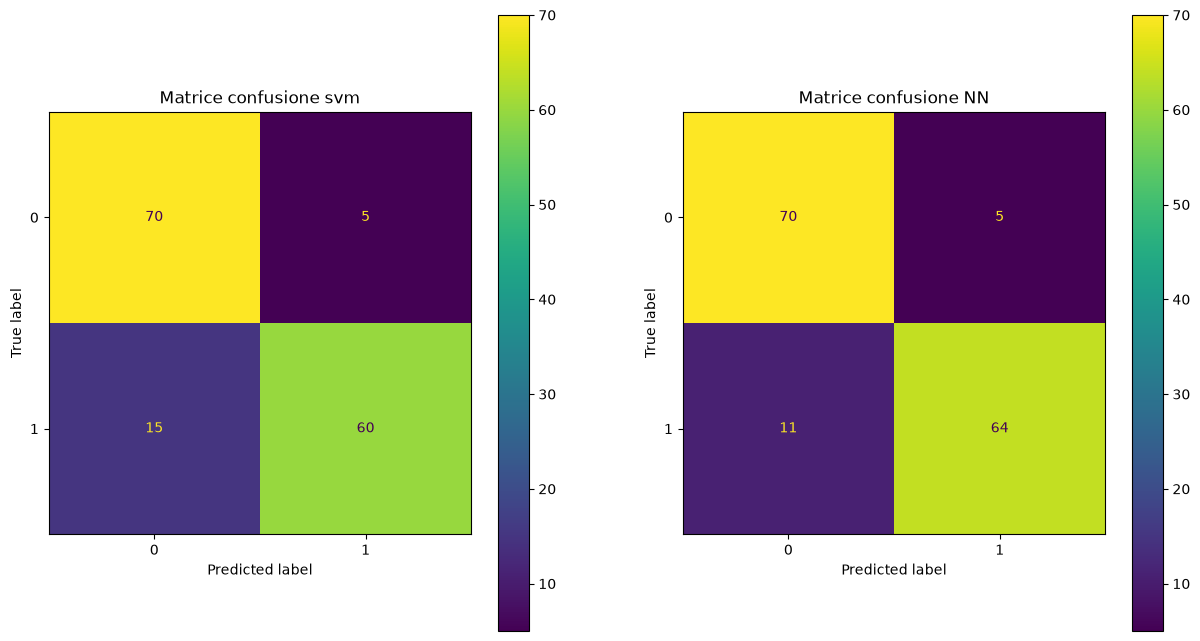

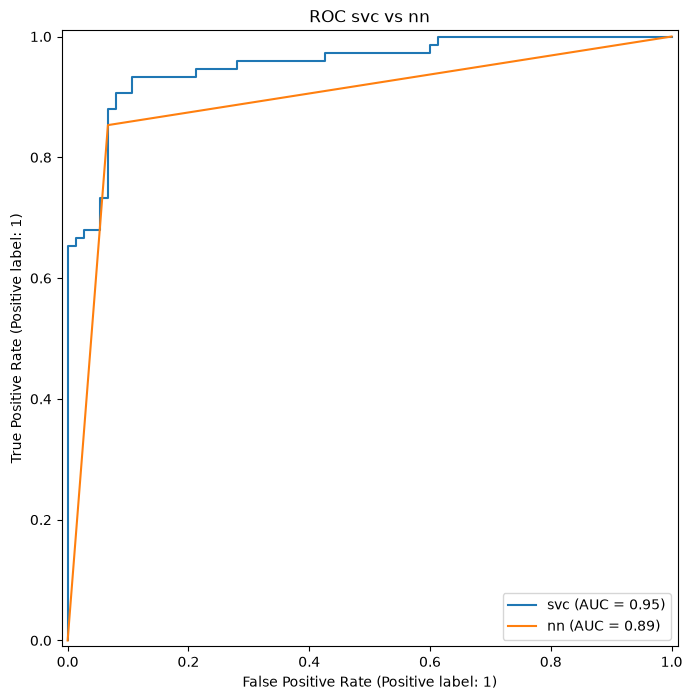

In [50]:
print(accuracy)
print(test_accuracy)

fig, ax = plt.subplots(1, 2, figsize=(15,8))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred, ax=ax[0])
ax[0].set_title("Matrice confusione svm")

ConfusionMatrixDisplay.from_predictions(pred[0], pred[1], ax=ax[1])
ax[1].set_title("Matrice confusione NN")

fig, ax = plt.subplots(1,1, figsize=(15,8))
RocCurveDisplay.from_predictions(y_te, y_pred_prob, ax=ax, name='svc')
RocCurveDisplay.from_predictions(pred[0], pred[1], ax=ax, name='nn')
ax.set_title("ROC svc vs nn")

